In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report
from scipy import sparse
from tabulate import tabulate  # Import tabulate
import warnings

warnings.filterwarnings("ignore")


In [2]:
# Load the dataset
df = pd.read_csv("PDP.csv")
df = df.dropna(subset=["Domain", "label"])
df.columns = df.columns.str.strip()  # Removes leading/trailing spaces

In [3]:
X_text = df["Domain"].astype(str)
y = df["label"]


In [4]:
# Step 2: TF-IDF Vectorization (character-level)
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 5))
X_vec = vectorizer.fit_transform(X_text)


In [5]:
# Step 3: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y, test_size=0.2, random_state=42
)

In [6]:
# --- Logistic Regression ---
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Training Accuracy (Logistic Regression)
y_train_pred_log = log_model.predict(X_train)
train_accuracy_log = accuracy_score(y_train, y_train_pred_log)
#print(f"\nLogistic Regression - Training Accuracy: {train_accuracy_log:.4f}")

# Testing Accuracy (Logistic Regression)
y_test_pred_log = log_model.predict(X_test)
test_accuracy_log = accuracy_score(y_test, y_test_pred_log)
#print(f"Logistic Regression - Testing Accuracy: {test_accuracy_log:.4f}")

In [7]:
# --- SGDClassifier ---
sgd_model = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)
sgd_model.fit(X_train, y_train)

# Training Accuracy (SGDClassifier)
y_train_pred_sgd = sgd_model.predict(X_train)
train_accuracy_sgd = accuracy_score(y_train, y_train_pred_sgd)
#print(f"\nSGDClassifier - Training Accuracy: {train_accuracy_sgd:.4f}")

# Testing Accuracy (SGDClassifier)
y_test_pred_sgd = sgd_model.predict(X_test)
test_accuracy_sgd = accuracy_score(y_test, y_test_pred_sgd)
#print(f"SGDClassifier - Testing Accuracy: {test_accuracy_sgd:.4f}")

In [8]:
table = [
    ["Model", "Train Accuracy", "Test Accuracy"],
    ["Logistic Regression", train_accuracy_log, test_accuracy_log],
    ["SGDClassifier", train_accuracy_sgd, test_accuracy_sgd],
]

# Print the table
print(tabulate(table, headers="firstrow", tablefmt="grid"))

+---------------------+------------------+-----------------+
| Model               |   Train Accuracy |   Test Accuracy |
+=====================+==================+=================+
| Logistic Regression |         0.920386 |        0.906381 |
+---------------------+------------------+-----------------+
| SGDClassifier       |         0.880277 |        0.880744 |
+---------------------+------------------+-----------------+


In [9]:
# Compare and pick the best (based on TESTING accuracy)
accuracies = {
    "Logistic Regression": test_accuracy_log,
    "SGDClassifier": test_accuracy_sgd,
}

best_model_name = max(accuracies, key=accuracies.get)
best_model_accuracy = accuracies[best_model_name]
print(
    f"\nBest model: {best_model_name} with Testing Accuracy:"
    f" {best_model_accuracy:.4f}"
)


Best model: Logistic Regression with Testing Accuracy: 0.9064


In [10]:
# Print classification report of the best model using tabulate
if best_model_name == "Logistic Regression":
    y_pred_best = y_test_pred_log
elif best_model_name == "SGDClassifier":
    y_pred_best = y_test_pred_sgd

report = classification_report(y_test, y_pred_best, output_dict=True)
df_report = pd.DataFrame(report).transpose()


print("\nClassification Report for the Best Model: Logistic_Regression\n")
print("Accuracy:", df_report.loc['accuracy', 'support'])
print(tabulate(df_report, headers='keys', tablefmt='grid'))


Classification Report for the Best Model: Logistic_Regression

Accuracy: 0.9063805424203227
+--------------+-------------+----------+------------+--------------+
|              |   precision |   recall |   f1-score |      support |
+==============+=============+==========+============+==============+
| 0            |    0.969514 | 0.805953 |   0.8802   | 20124        |
+--------------+-------------+----------+------------+--------------+
| 1            |    0.871673 | 0.981136 |   0.923171 | 27035        |
+--------------+-------------+----------+------------+--------------+
| accuracy     |    0.906381 | 0.906381 |   0.906381 |     0.906381 |
+--------------+-------------+----------+------------+--------------+
| macro avg    |    0.920593 | 0.893544 |   0.901685 | 47159        |
+--------------+-------------+----------+------------+--------------+
| weighted avg |    0.913424 | 0.906381 |   0.904834 | 47159        |
+--------------+-------------+----------+------------+-------------

In [11]:
# VISUALIZATION (rest of your code remains the same)
label_counts = df['label'].value_counts()

In [12]:
# Count phishing vs legitimate URL
phishing_urls = df[df["label"] == 1].shape[0]
legitimate_urls = df[df["label"] == 0].shape[0]

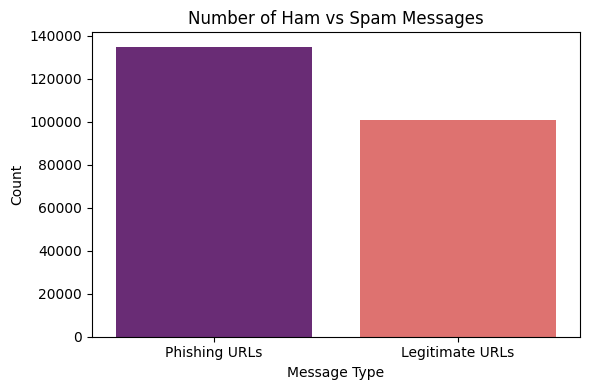

In [13]:
plt.figure(figsize=(6,4))
sns.barplot(x=["Phishing URLs", "Legitimate URLs"], 
            y=[phishing_urls, legitimate_urls], 
            palette="magma")
plt.title('Number of Ham vs Spam Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()